In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
words = open("names.txt", "r").read().splitlines()

In [4]:
chars = sorted(list(set("".join(words))))
str_to_int = {str: (int + 1) for int, str in enumerate(chars)}
str_to_int["."] = 0
int_to_str = {int: str for str, int in str_to_int.items()}

print(int_to_str)
print(str_to_int)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


In [5]:
def build_dataset(words: list):
    block_size = 3
    X, Y = [], []

    for w in words:
        window = [0] * block_size # create a sliding window of size defined by block_size that starts as ...
        for c in w + '.':
            ix = str_to_int[c]
            X.append(window)
            Y.append(ix)
            #print("".join(int_to_str[i] for i in window), " --->", c)
            window = window[1:] + [ix] # crop out the first character and add the next character
    
    X, Y = torch.tensor(X), torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y
    
import random
random.seed(42)

random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

print(len(words), n1, n2)

Xtr, Ytr = build_dataset(words[:n1])
Xval, Yval = build_dataset(words[n1: n2])
Xtest, Ytest = build_dataset(words[n2:])

32033 25626 28829
torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [6]:
n_emb = 10
n_hidden = 200 

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, n_emb), generator=g)
W1 = torch.randn((30, n_hidden), generator=g) # W1.shape[0] was 3 * C.shape[1] before, so 3 * 10 is 30
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, 27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

11897


In [7]:
steps = 200000
batch_size = 32
lossi = []

for i in range(steps):
    # create minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,)) # creates a tuple of size 32 with range (0, 228146)
    
    # sample
    emb = C[Xtr[ix]] # convert chars to vectors
    emb_cat = emb.view(emb.shape[0], -1) # concatenate vectors
    h_pre_act = emb_cat @ W1 + b1 # hidden layer pre-activation
    h = torch.tanh(h_pre_act) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Ytr[ix])
    
    for p in parameters:
        p.grad = None
    loss.backward()
    
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
        
    if i % 10000 == 0:
        print(f"Step {i}/{steps}: {loss.item():.3f}")
    #lossi.append(loss.log10().item())
    lossi.append(loss.item())
    break

Step 0/200000: 29.742


A truly random operator will have all logits equal to a certain value if there are 27 possible output neurons/choices in the first pass of the training loop since weights aren't modified at all. If we check the non modified weights' logits then we get something very different as the distribution is skewed with very extreme values on either ends among logits. Let's understand via doing

In [8]:
logits[0]

tensor([-20.2110,   5.6692,   6.1563, -18.2817,  18.4339,  25.0189, -13.4923,
         23.5851,   5.7153,   7.7879,  20.7401,  -5.7500,  -7.1466,  -1.3988,
          5.0008,  14.7652, -19.8160,   6.5872,   5.6275,   3.0389,  -2.8325,
         34.4852,   0.7360, -15.3698,  -2.4497,   3.7273,   2.9899],
       grad_fn=<SelectBackward0>)

See? let's now see what a proper distribution should have

In [9]:
logits = torch.tensor([2.0, 2.0, 2.0, 2.0])
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
logits, probs, loss

(tensor([2., 2., 2., 2.]),
 tensor([0.2500, 0.2500, 0.2500, 0.2500]),
 tensor(1.3863))

In [10]:
# now, for a tensor with 27 neurons, the ideal value should be given by
-torch.tensor(1/27.0).log()


tensor(3.2958)

## Fixing init loss
Naturally, there will be some entropy mixed in which we can't completely remove, but we can try to be as close as possible by removing bias value for output altogether and reducing the output weights to very low values. 

In [11]:
n_emb = 10
n_hidden = 200 

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, n_emb), generator=g)
W1 = torch.randn((30, n_hidden), generator=g) # W1.shape[0] was 3 * C.shape[1] before, so 3 * 10 is 30. this is because when we do emb.view(emb.shape[0], -1)- we concatenate the 3 character embeddings(cuz trigram) into 3 * 10 = 30. so we match input size of W1
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, 27), generator=g) * 0.01 # HERE. lowering the output layer weights to decrease the initial loss value
b2 = torch.randn(27, generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

11897


In [12]:
steps = 10000
batch_size = 32
lossi = []

for i in range(steps):
    # create minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,)) # creates a tuple of size 32 with range (0, 228146)
    
    # sample
    emb = C[Xtr[ix]] # convert chars to vectors, shape: (batch_size, 3, n_emb)
    emb_cat = emb.view(emb.shape[0], -1) # concatenate vectors, shape: (batch_size, 30)
    h_pre_act = emb_cat @ W1 + b1 # hidden layer pre-activation, shape: (batch_size, n_hidden)
    h = torch.tanh(h_pre_act) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Ytr[ix])
    
    for p in parameters:
        p.grad = None
    loss.backward()
    
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
        
    if i % 10000 == 0:
        print(f"Step {i}/{steps}: {loss.item():.3f}")
    lossi.append(loss.log10().item()) # to make graph smoother and less rough
    if i > 10000:
        break

Step 0/10000: 3.293


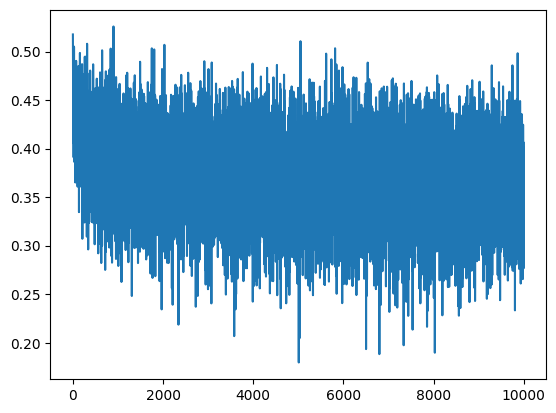

In [13]:
plt.plot(lossi)

Now the graph won't look like a hockey stick since we removed the "easier" parts of the loss present in the beginning.

## Fixing saturated tanh
Our tanh is currently taking in values and putting them equal to +1 or -1 but that actually creates dead neurons because tanh'(x)= 1 - tan^2(x) and that is 0 when tan(x) is -1 or +1. let's understand via examples again

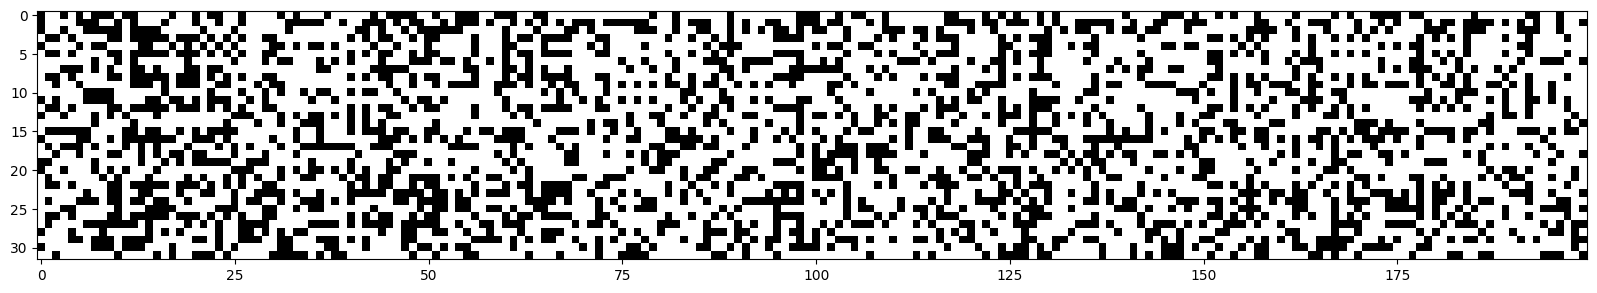

In [14]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

(array([2224.,  143.,   99.,   63.,   39.,   40.,   30.,   32.,   55.,
          35.,   31.,   32.,   34.,   15.,   18.,   19.,   45.,    8.,
          28.,   18.,   32.,   11.,   16.,   23.,   28.,   35.,   26.,
          16.,   24.,   39.,   18.,   26.,   18.,   17.,   31.,   23.,
          19.,   19.,   14.,   30.,   28.,   45.,   65.,   26.,   43.,
          49.,   44.,   74.,  147., 2406.]),
 array([-1.  , -0.96, -0.92, -0.88, -0.84, -0.8 , -0.76, -0.72, -0.68,
        -0.64, -0.6 , -0.56, -0.52, -0.48, -0.44, -0.4 , -0.36, -0.32,
        -0.28, -0.24, -0.2 , -0.16, -0.12, -0.08, -0.04,  0.  ,  0.04,
         0.08,  0.12,  0.16,  0.2 ,  0.24,  0.28,  0.32,  0.36,  0.4 ,
         0.44,  0.48,  0.52,  0.56,  0.6 ,  0.64,  0.68,  0.72,  0.76,
         0.8 ,  0.84,  0.88,  0.92,  0.96,  1.  ]),
 <BarContainer object of 50 artists>)

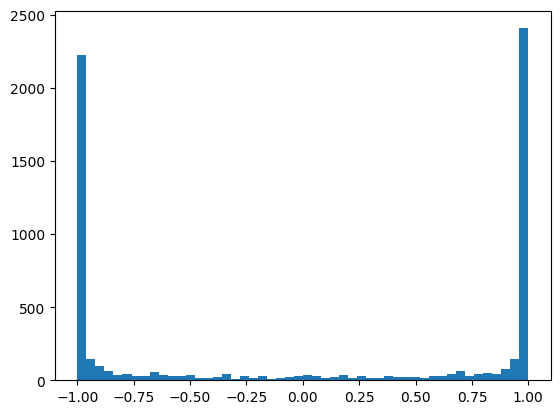

In [15]:
# put values into equal width bins to count how many values fall in each
plt.hist(h.view(-1).tolist(), 50)

(array([  3.,   0.,   2.,   0.,   5.,   6.,   7.,  13.,  26.,  27.,  35.,
         51.,  77.,  94., 119., 183., 165., 231., 262., 298., 359., 307.,
        345., 435., 434., 351., 355., 321., 318., 323., 279., 208., 149.,
        160., 115.,  78.,  93.,  41.,  36.,  23.,  17.,  12.,  10.,  11.,
          6.,   1.,   8.,   0.,   0.,   1.]),
 array([-20.34309006, -19.5006496 , -18.65820915, -17.8157687 ,
        -16.97332825, -16.13088779, -15.28844734, -14.44600689,
        -13.60356644, -12.76112598, -11.91868553, -11.07624508,
        -10.23380463,  -9.39136417,  -8.54892372,  -7.70648327,
         -6.86404282,  -6.02160236,  -5.17916191,  -4.33672146,
         -3.49428101,  -2.65184055,  -1.8094001 ,  -0.96695965,
         -0.1245192 ,   0.71792126,   1.56036171,   2.40280216,
          3.24524261,   4.08768307,   4.93012352,   5.77256397,
          6.61500443,   7.45744488,   8.29988533,   9.14232578,
          9.98476624,  10.82720669,  11.66964714,  12.51208759,
         13.354528

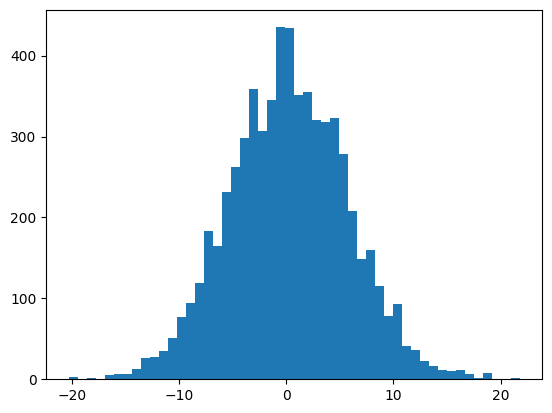

In [16]:
plt.hist(h_pre_act.view(-1).tolist(), 50)

You can see that the distribution for h is absolutely tilting towards the tail ends, and the tanh curve makes them flat. This leads to what we discussed earlier. 


The solution is pretty simple. Since `h` is reliant on `h_pre_act` and `h_pre_act` is reliant on W1 and B1- we do the same to them as we did to W2 and B2 in previous section while fixing initialization loss.

In [17]:
n_emb = 10
n_hidden = 200 

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, n_emb), generator=g)
W1 = torch.randn((30, n_hidden), generator=g) * 0.2 # cus we do need some whites
b1 = torch.randn(n_hidden, generator=g) * 0.01 # just leaving some out for generalization/entropy
W2 = torch.randn((n_hidden, 27), generator=g) * 0.01 # HERE. lowering the output layer weights to decrease the initial loss value
b2 = torch.randn(27, generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

11897


In [18]:
steps = 200000
batch_size = 32
lossi = []

for i in range(steps):
    # create minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,)) # creates a tuple of size 32 with range (0, 228146)
    
    # sample
    emb = C[Xtr[ix]] # convert chars to vectors, shape: (batch_size, 3, n_emb)
    emb_cat = emb.view(emb.shape[0], -1) # concatenate vectors, shape: (batch_size, 30)
    h_pre_act = emb_cat @ W1 + b1 # hidden layer pre-activation, shape: (batch_size, n_hidden)
    h = torch.tanh(h_pre_act) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Ytr[ix])
    
    for p in parameters:
        p.grad = None
    loss.backward()
    
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
        
    if i % 10000 == 0:
        print(f"Step {i}/{steps}: {loss.item():.3f}")
    lossi.append(loss.log10().item()) # to make graph smoother and less rough
    break

Step 0/200000: 3.323


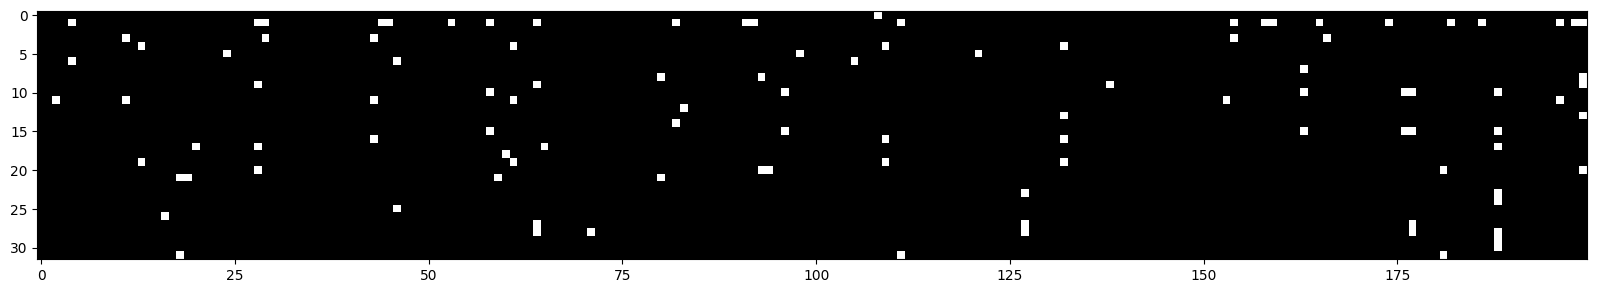

In [19]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest') # shows white if true, else not

(array([196., 207., 175., 167., 154., 151., 161., 119.,  98., 119., 101.,
        115., 113., 108., 106., 100.,  96.,  86., 115.,  82., 104.,  89.,
         90., 106.,  82., 114.,  78., 113.,  88.,  96., 102., 116., 116.,
         90., 103., 113., 102., 119., 119., 125., 122., 136., 132., 170.,
        143., 187., 171., 204., 236., 265.]),
 array([-9.99378622e-01, -9.59396585e-01, -9.19414549e-01, -8.79432513e-01,
        -8.39450476e-01, -7.99468440e-01, -7.59486403e-01, -7.19504367e-01,
        -6.79522331e-01, -6.39540294e-01, -5.99558258e-01, -5.59576222e-01,
        -5.19594185e-01, -4.79612149e-01, -4.39630113e-01, -3.99648076e-01,
        -3.59666040e-01, -3.19684004e-01, -2.79701967e-01, -2.39719931e-01,
        -1.99737895e-01, -1.59755858e-01, -1.19773822e-01, -7.97917855e-02,
        -3.98097491e-02,  1.72287226e-04,  4.01543236e-02,  8.01363599e-02,
         1.20118396e-01,  1.60100433e-01,  2.00082469e-01,  2.40064505e-01,
         2.80046542e-01,  3.20028578e-01,  3.60010

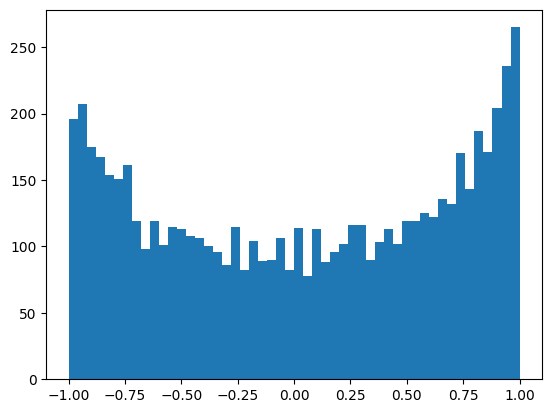

In [20]:
plt.hist(h.view(-1).tolist(), 50)

Already much better!

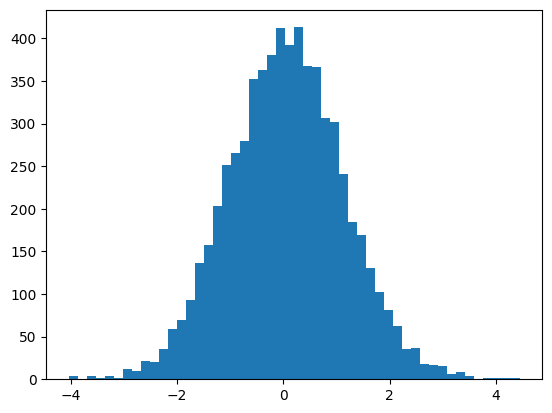

In [21]:
plt.hist(h_pre_act.view(-1).tolist(), 50);

In [22]:
@torch.no_grad() # disable gradient tracking
def split_loss(split):
    x, y = {
        "train": (Xtr, Ytr),
        "val": (Xval, Yval),
        "test": (Xtest, Ytest)
    }[split]
    emb = C[x] # (N, 3, n_emb), 3 is block_size
    embcat = emb.view(emb.shape[0], -1) # concats into (N, 3 * n_emb)
    h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size), vocab_size is 27
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())
    
split_loss('train')
split_loss('val')

train 3.2473275661468506
val 3.2471749782562256


If we use this after training in full, the validation loss goes down a lot since we have fixed two major bugs(initialization loss and saturation of tanh in flat tails).

## Kaiming Initialization of weights
We need to boost weights a bit to fight against the contractive operation performed by tanh or other activations which squeeze values into a particular range(EG. relu which shuts down any negative input).

This brings us to Kaiming init, which divides the weights by the sqrt of Fan_in(number of input neurons) to normalize the weights. Accessible in torch api via `torch.nn.init.kaiming_normal_`. The value of this factor differs from activation to activation. For tanh it's `(5/3)/(Fan_in**0.5)`

tensor(0.0169) tensor(1.0065)
tensor(-0.0022) tensor(0.9975)


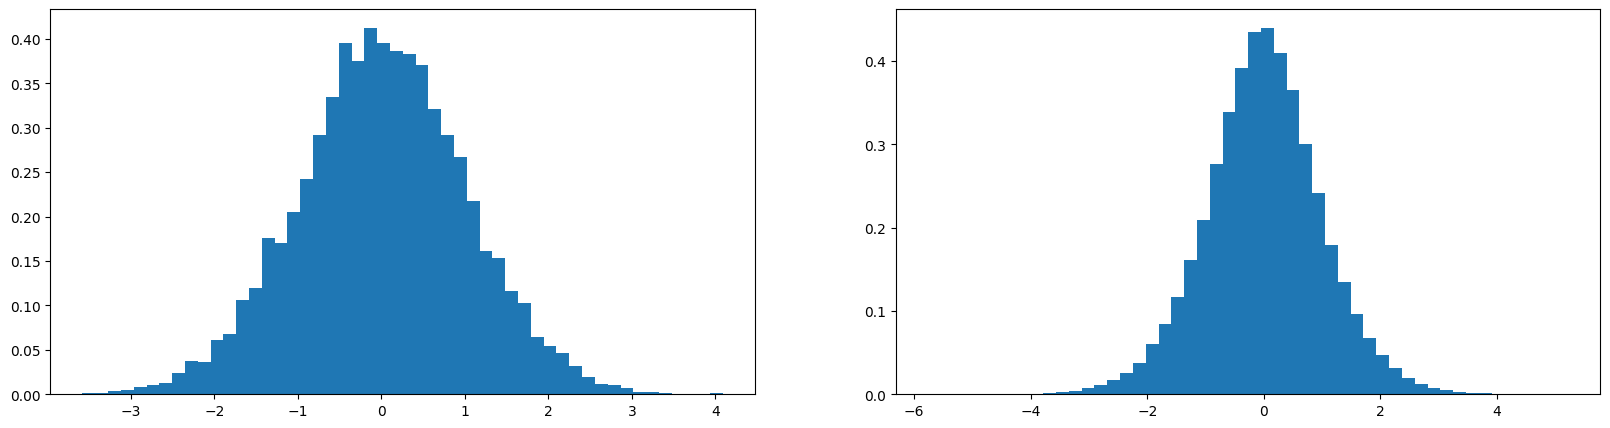

In [23]:
x = torch.randn(1000, 10) # input
w = torch.randn(10, 200) / 10 ** 0.5 # fan_in here is 10. though in our n/w's case it's actually 30 cuz we contatenate n_emb with block_size
# we can also multiply W by the true factor (5/3) / (10 **0.5)
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std()) # y's std will be much higher than x's if we don't regularize the weights' initialization
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True);

One reason they are not so popular anymore are due to the fact that complex optimizers(like RMSprop), batchnorm/layernorm, residual connections etc have made training more stable and well behaved so it's not really needed as much. You can still use it ofcourse!

## BatchNorm
Normalizes the hidden layers pre-activation to yield more stable training results. With time, we switched to methods like LayerNorm and GroupNorm which mitigated some of the issues BatchNorm brought, like 
- how it depends on the batch size to bring true regularization and being too big or too small can lead to issues.
- we use running averages caught during training to use during inference as the batch size is just 1 at that time. if the training distribution differs even slightly from that of test-time- those averages hurt inference performance.
- the output for one sample becomes a function of other samples in the batch.

Those were the few problems it brought, however the main reason it was so good at that time was that both the `mean` and `std` are noisy estimates of the true population statistics(since derived via mini batch), so each sample gets normalized by a different factor, depending on the batch neighbours. So the network can't really overfit since it's being regularized to not remember any sample's exact representation.

The formula is quite simple,

just take mean and std of all hidden preactivations in a batch, then subtract by the mean and divide by std!

Once done, multiply by a gain value and add a bias value to ensure that we don't constrain our internal representations to zero mean and unit variance. The two factors are learned parameters that will ensure that the network has sufficient capacity to learn across a large enough range which can be optimal. These two values offset and scale the internal representations during training.

In [24]:
print(h.mean(0, keepdim=True).shape) # mean across batches(dim 0)
print(h.std(0, keepdim=True).shape)

torch.Size([1, 200])
torch.Size([1, 200])


In [25]:
n_emb = 10
n_hidden = 200
block_size = 3

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, n_emb), generator=g)
W1 = torch.randn((n_emb * block_size, n_hidden), generator=g) * (5/3) / ((n_emb * block_size)**0.5)
b1 = torch.randn(n_hidden, generator=g) * 0.01 # just leaving some out for generalization/entropy
W2 = torch.randn((n_hidden, 27), generator=g) * 0.01 
b2 = torch.randn(27, generator=g) * 0

bn_gain = torch.ones((1, n_hidden)) # batch_norm gain!
bn_bias = torch.zeros((1, n_hidden)) # batch_norm bias!

parameters = [C, W1, b1, W2, b2, bn_gain, bn_bias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

12297


In [26]:
steps = 200000
batch_size = 32
lossi = []

for i in range(steps):
    # create minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,)) # creates a tuple of size 32 with range (0, 228146)
    
    # sample
    emb = C[Xtr[ix]] # convert chars to vectors, shape: (batch_size, 3, n_emb)
    emb_cat = emb.view(emb.shape[0], -1) # concatenate vectors, shape: (batch_size, 30)
    h_pre_act = emb_cat @ W1 + b1 # hidden layer pre-activation, shape: (batch_size, n_hidden)
    h_pre_act = bn_gain * (h_pre_act - h_pre_act.mean(0, keepdim=True)) / (h_pre_act.std(0, keepdim=True) + 10e-8) + bn_bias # batch normalization goes HERE
    h = torch.tanh(h_pre_act) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Ytr[ix])
    
    for p in parameters:
        p.grad = None
    loss.backward()
    
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
        
    if i % 10000 == 0:
        print(f"Step {i}/{steps}: {loss.item():.3f}")
    lossi.append(loss.log10().item()) # to make graph smoother and less rough
    break

Step 0/200000: 3.295


In [28]:
# calculate batch norm at end of training for inference since we don't have access to those values otherwise.
with torch.no_grad():
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    h_pre_act = embcat @ W1 + b1
    # measure mean/std over entire training set
    bn_mean = h_pre_act.mean(0, keepdim=True)
    bn_std = h_pre_act.std(0, keepdim=True)

In [29]:
# check loss
@torch.no_grad() # disable gradient tracking
def split_loss(split):
    x, y = {
        "train": (Xtr, Ytr),
        "val": (Xval, Yval),
        "test": (Xtest, Ytest)
    }[split]
    emb = C[x] # (N, 3, n_emb), 3 is block_size
    embcat = emb.view(emb.shape[0], -1) # concats into (N, 3 * n_emb)
    h_pre_act = embcat @ W1 + b1
    h_pre_act = bn_gain * (h_pre_act - bn_mean) / (bn_std + 10e-8) + bn_bias
    h = torch.tanh(h_pre_act) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size), vocab_size is 27
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())
    
split_loss('train')
split_loss('val')

train 3.2785050868988037
val 3.277393341064453


Calculating mean and std after training for inference is a pain, so we just maintain running averages of mean and std instead. PS. We don't need to add bias in linear layer while using batchnorm!

In [37]:
n_emb = 10
n_hidden = 200
block_size = 3

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, n_emb), generator=g)
W1 = torch.randn((n_emb * block_size, n_hidden), generator=g) * (5/3) / ((n_emb * block_size)**0.5)
b1 = torch.randn(n_hidden, generator=g) * 0.01 # just leaving some out for generalization/entropy
W2 = torch.randn((n_hidden, 27), generator=g) * 0.01 
b2 = torch.randn(27, generator=g) * 0

bn_gain = torch.ones((1, n_hidden)) # batch_norm gain!
bn_bias = torch.zeros((1, n_hidden)) # batch_norm bias!
bn_mean_running = torch.ones((1, n_hidden))
bn_std_running = torch.zeros((1, n_hidden))


parameters = [C, W1, b1, W2, b2, bn_gain, bn_bias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

12297


In [38]:
steps = 200000
batch_size = 32
lossi = []

for i in range(steps):
    # create minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,)) # creates a tuple of size 32 with range (0, 228146)
    
    # forward pass
    emb = C[Xtr[ix]] # convert chars to vectors, shape: (batch_size, 3, n_emb)
    emb_cat = emb.view(emb.shape[0], -1) # concatenate vectors, shape: (batch_size, 30)
    # ---------Linear Layer ---------------
    h_pre_act = emb_cat @ W1 #+ b1 # hidden layer pre-activation, shape: (batch_size, n_hidden)
    # --------Batch Norm Layer --------------
    bn_mean_i = h_pre_act.mean(0, keepdim=True)
    bn_std_i = h_pre_act.std(0, keepdim=True)
    h_pre_act = bn_gain * (h_pre_act - bn_mean_i) / (bn_std_i + 10e-8) + bn_bias # batch normalization goes HERE
    with torch.no_grad():
        bn_mean_running = 0.999 * bn_mean_running + 0.001 * bn_mean_i
        bn_std_running = 0.999 * bn_std_running + 0.001 * bn_std_i
    # --------Non-Linearity------------------
    h = torch.tanh(h_pre_act) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Ytr[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
        
    if i % 10000 == 0:
        print(f"Step {i}/{steps}: {loss.item():.3f}")
    lossi.append(loss.log10().item()) # to make graph smoother and less rough
    #break

Step 0/200000: 3.343
Step 10000/200000: 2.550
Step 20000/200000: 2.413
Step 30000/200000: 2.147
Step 40000/200000: 2.064
Step 50000/200000: 2.284
Step 60000/200000: 2.330
Step 70000/200000: 1.716
Step 80000/200000: 2.623
Step 90000/200000: 1.851
Step 100000/200000: 2.015
Step 110000/200000: 2.261
Step 120000/200000: 1.954
Step 130000/200000: 2.339
Step 140000/200000: 2.046
Step 150000/200000: 2.324
Step 160000/200000: 2.213
Step 170000/200000: 1.938
Step 180000/200000: 1.854
Step 190000/200000: 2.115


In [39]:
# calculate batch norm at end of training for inference since we don't have access to those values otherwise.
with torch.no_grad():
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    h_pre_act = embcat @ W1 + b1
    # measure mean/std over entire training set
    bn_mean = h_pre_act.mean(0, keepdim=True)
    bn_std = h_pre_act.std(0, keepdim=True)

In [40]:
print(bn_std)

tensor([[2.4071, 2.0964, 2.0170, 2.2290, 2.1746, 2.3720, 2.2346, 2.2105, 2.5411,
         2.2171, 2.4354, 2.1059, 2.2726, 2.1905, 2.0944, 2.8594, 2.3098, 2.2658,
         2.1770, 2.6479, 2.4121, 2.2900, 1.9559, 2.2473, 2.0311, 1.9249, 2.0460,
         2.2591, 2.5717, 2.4984, 1.3455, 2.0522, 2.0441, 2.0298, 1.7005, 1.7095,
         2.6086, 2.1300, 1.7453, 1.9270, 2.1257, 1.9521, 2.3677, 1.7429, 2.2118,
         2.4217, 2.1810, 2.6739, 2.7825, 2.4445, 2.1220, 1.8349, 2.0130, 1.6325,
         2.3905, 2.2257, 1.7977, 2.1563, 2.4237, 2.1137, 1.9491, 2.1803, 1.9421,
         2.2963, 2.1952, 2.3334, 2.1003, 2.4736, 1.9498, 2.0380, 2.2946, 1.9105,
         2.0889, 2.0675, 1.8899, 1.8779, 2.3948, 2.2051, 1.6659, 2.4673, 1.9879,
         1.5910, 2.1273, 2.4214, 2.3673, 2.2494, 2.2588, 2.4641, 2.6287, 2.6609,
         1.9940, 1.8863, 2.0565, 1.9712, 2.0001, 2.4723, 1.9846, 2.0021, 2.1648,
         2.1034, 2.5756, 2.0656, 2.1973, 2.0723, 2.0388, 2.2524, 1.9396, 2.1457,
         2.0325, 1.7246, 2.3

In [41]:
print(bn_std_running)

tensor([[2.3872, 2.0745, 1.9887, 2.1981, 2.1482, 2.3365, 2.2176, 2.1718, 2.5155,
         2.1911, 2.4163, 2.0751, 2.2547, 2.1579, 2.0767, 2.8276, 2.2763, 2.2344,
         2.1646, 2.6279, 2.3850, 2.2504, 1.9347, 2.2234, 2.0113, 1.9004, 2.0190,
         2.2337, 2.5408, 2.4748, 1.3316, 2.0234, 2.0370, 2.0022, 1.6840, 1.6930,
         2.5884, 2.1195, 1.7326, 1.9103, 2.0992, 1.9315, 2.3557, 1.7222, 2.1788,
         2.4121, 2.1496, 2.6138, 2.7729, 2.4220, 2.1010, 1.8016, 1.9831, 1.6122,
         2.3772, 2.2049, 1.7824, 2.1334, 2.4008, 2.0825, 1.9304, 2.1476, 1.9315,
         2.2706, 2.1723, 2.3085, 2.0793, 2.4611, 1.9255, 2.0190, 2.2711, 1.8924,
         2.0642, 2.0469, 1.8568, 1.8562, 2.3652, 2.1837, 1.6522, 2.4382, 1.9706,
         1.5686, 2.0969, 2.3926, 2.3326, 2.2198, 2.2291, 2.4485, 2.6119, 2.6142,
         1.9689, 1.8711, 2.0369, 1.9471, 1.9745, 2.4529, 1.9625, 1.9811, 2.1434,
         2.0849, 2.5512, 2.0399, 2.1613, 2.0553, 2.0135, 2.2353, 1.9082, 2.1100,
         2.0055, 1.7010, 2.3

Nearly the same values!